In [1]:
import json
import os
import kagglehub
import importlib
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import pandas as pd
from IPython.display import JSON
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from functools import partial
from src.jsonl_dataset import JsonLDataset

In [2]:
# Raw dataset
path = kagglehub.dataset_download("Cornell-University/arxiv/versions/272")
ds_path = os.path.join(path, 'arxiv-metadata-oai-snapshot.json')
ds = JsonLDataset(ds_path)

# Categories hierarchy
categories_hierarchy = json.load(open("resources/categories_hierarchy.json", 'r'))

# Augmented index
df = pd.read_json("resources/augmented_index.jsonl", lines=True)
df.columns = ["Index", "Raw categories", "Parent categories", "Remapped categories"]

Indexing dataset at C:\Users\kerem\.cache\kagglehub\datasets\Cornell-University\arxiv\versions\272\arxiv-metadata-oai-snapshot.json... (this may take a minute)
Indexed 2951540 entries.


In [3]:
def filter_by_parent_category(df: pd.DataFrame, c_filter: str) -> pd.DataFrame:
    return df[df["Parent categories"].apply(lambda categories: c_filter in categories)].reset_index(drop=True)

In [8]:
df_parents = {}
for k in tqdm(categories_hierarchy.keys()):
    df_filtered = filter_by_parent_category(df, k)
    df_parents[k] = df_filtered

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:18<00:00,  2.05s/it]


In [16]:
# Integrity check
def integrity_check(df_parents, categories_hierarchy):
    print("Checking data integrity")
    error = False
    for key, df in tqdm(df_parents.items()):
        total_count_in_categories = categories_hierarchy[key]["count"]
        parent_categories_count = df["Parent categories"].apply(lambda c: c.count(key)).sum()
        if total_count_in_categories != parent_categories_count:
            print(f"""
                Missmatch in tags count for parent category: {key}
                Found: {total_count_in_categories} tags in categories_hierarchy
                And    {parent_categories_count} tags in the augmented index
            """)
            error = True
    if not error:
        print("Alles gut :D")

integrity_check(df_parents, categories_hierarchy)

Checking data integrity


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:04<00:00,  2.22it/s]

Alles gut:D


In [33]:
def plot_parent_distribution(df_parents: dict[str, "pd.DataFrame"]) -> None:
    """
    Creates an interactive bar chart showing the number of samples per parent category.
    """
    import plotly.graph_objects as go

    labels = list(df_parents.keys())
    values = [len(df) for df in df_parents.values()]

    sorted_pairs = sorted(zip(labels, values), key=lambda x: x[1], reverse=True)
    labels, values = zip(*sorted_pairs)

    fig = go.Figure(
        data=go.Bar(
            x=list(labels),
            y=list(values),
            marker_color=[
                "#636EFA", "#EF553B", "#00CC96", "#AB63FA",
                "#FFA15A", "#19D3F3", "#FF6692", "#B6E880",
            ][:len(labels)],
            hovertemplate="<b>%{x}</b><br>Count: %{y:,}<extra></extra>",
        )
    )

    fig.update_layout(
        title="Paper count by Parent Category",
        xaxis_title="Parent Category",
        yaxis_title="Number of Samples",
        yaxis_tickformat=",",
        template="plotly_white",
        height=700,
    )

    fig.show()

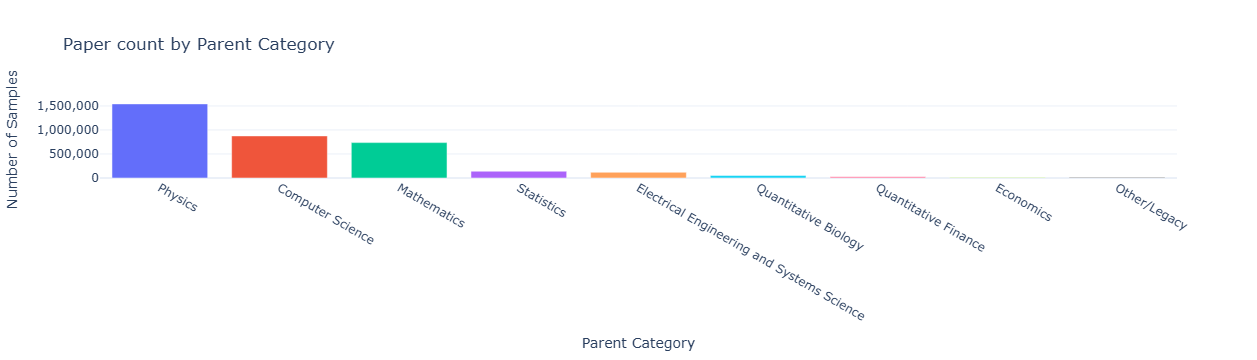

In [119]:
plot_parent_distribution(df_parents)

In [120]:
import numpy as np

def sample_indices_by_parent(
    df_parents: dict[str, pd.DataFrame],
    n_samples_per_class: int = 10_000,
    n_test_per_class: int = 2_000,
    random_state: int | None = None,
    classes_to_skip: list[str] = []
) -> tuple[np.ndarray, np.ndarray]:
    """
    Sample up to n_samples_per_class rows per parent for train, and up to
    n_test_per_class from the remainder for test. Train and test are disjoint.
    Returns (train_indices, test_indices), both 2D arrays from the Index table.
    """
    rng = np.random.default_rng(random_state)
    train_indices = []
    test_indices = []
    for key, parent_df in df_parents.items():
        if key in classes_to_skip:
            continue
        idx = parent_df["Index"].values
        n_total = len(idx)
        order = rng.permutation(n_total)
        n_train = min(n_samples_per_class, n_total)
        n_test = min(n_test_per_class, n_total - n_train)
        train_indices.append(idx[order[:n_train]].tolist())
        test_indices.append(idx[order[n_train : n_train + n_test]].tolist())
    return np.array(train_indices), np.array(test_indices)

train_indices, test_indices = sample_indices_by_parent(
    df_parents, n_samples_per_class=10_000, n_test_per_class=2_000, random_state=42, classes_to_skip=["Other/Legacy"]
)
print(f"Train: {sum(len(row) for row in train_indices)} indices")
print(f"Test: {sum(len(row) for row in test_indices)} indices")

Train: 80000 indices
Test: 16000 indices


In [169]:
train_indices.shape

(8, 10000)

In [178]:
def save_indices_to_jsonl(indices_array, output_path):   
    with open(output_path, 'w') as f:
        for row in indices_array:
            # Dump the list directly. No dictionary wrapper.
            f.write(json.dumps(row.tolist()) + '\n')

In [180]:
save_indices_to_jsonl(train_indices, "resources/train_indicies_parent_categories.jsonl")
save_indices_to_jsonl(test_indices, "resources/test_indices_parent_categories.jsonl")

### Validation

In [181]:
categories_hierarchy.keys()

dict_keys(['Physics', 'Mathematics', 'Computer Science', 'Quantitative Biology', 'Statistics', 'Quantitative Finance', 'Economics', 'Electrical Engineering and Systems Science', 'Other/Legacy'])

In [167]:
rand_idx = random.choice(test_indices[1])
print(df.iloc[rand_idx])
print("\n\n")
print(json.dumps(ds[rand_idx], indent=4))

Index                                               219082
Raw categories                     math-ph math.AP math.MP
Parent categories      [Physics, Mathematics, Mathematics]
Remapped categories            [math-ph, math.AP, math.MP]
Name: 219082, dtype: object



{
    "id": "1010.2694",
    "submitter": "Vincent Duch\\^ene M.",
    "authors": "Vincent Duch\\^ene, Michael I. Weinstein",
    "title": "Scattering, homogenization and interface effects for oscillatory\n  potentials with strong singularities",
    "comments": "To appear in SIAM Multiscale Modeling, Analysis and Simulation (2011)",
    "journal-ref": "Multiscale Model. Simul., 9, pp. 1017-1063 (2011)",
    "doi": "10.1137/100811672",
    "report-no": null,
    "categories": "math-ph math.AP math.MP",
    "license": "http://arxiv.org/licenses/nonexclusive-distrib/1.0/",
    "abstract": "  We study one-dimensional scattering for a decaying potential with rapid\nperiodic oscillations and strong localized singularities. In pa